# 04 — Escalamiento y PCA

**Objetivo de esta etapa:** aplicar escalamiento a las variables numéricas y reducir su
dimensionalidad mediante PCA (Análisis de Componentes Principales), documentando las
variables utilizadas, el escalamiento aplicado, la varianza explicada y la
interpretación de las componentes obtenidas.

**Variables utilizadas:** `age`, `monthly_watch_time_mins` y `customer_support_tickets`
— las tres variables numéricas del dataset. No se incluyen `user_id` (identificador, sin
valor analítico) ni las variables categóricas, que quedan fuera del alcance de PCA
clásico (aunque podrían codificarse en un trabajo futuro).


## 0. Entorno de ejecución (Google Colab / local)

Si corre en Colab, monta Google Drive y usa `BASE_PATH` apuntando a la carpeta del
proyecto en tu Drive (subí `PI_Mineria_Datos_1/` completa, con `data/processed/` ya
generado por el notebook 02). Si corre localmente, usa la ruta relativa habitual.


In [1]:
import os

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

BASE_PATH = "/content/drive/MyDrive/PI_Mineria_Datos_1" if IN_COLAB else ".."

print(f"Ejecutando en Colab: {IN_COLAB}")
print(f"BASE_PATH: {BASE_PATH}")


Ejecutando en Colab: False
BASE_PATH: ..


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

plt.rcParams["figure.dpi"] = 100

df = pd.read_csv(f"{BASE_PATH}/data/processed/streaming_users_clean.csv")
num_cols = ["age", "monthly_watch_time_mins", "customer_support_tickets"]
X = df[num_cols]
X.describe()


## 1. Escalamiento

**Decisión:** se aplica `StandardScaler` (media 0, desvío estándar 1) en lugar de un
escalamiento min-max, porque las variables tienen unidades y rangos muy distintos (edad
en años, minutos en cientos/miles, tickets en unidades bajas) y PCA es sensible a la
escala: sin estandarizar, `monthly_watch_time_mins` dominaría la varianza total solo por
tener valores numéricamente más grandes, no porque sea más informativa.


In [3]:
scaler = StandardScaler()
X_esc = scaler.fit_transform(X)

X_esc_df = pd.DataFrame(X_esc, columns=num_cols)
print("Medias tras escalar (deberían ser ~0):")
print(X_esc_df.mean().round(3))
print("\nDesvíos tras escalar (deberían ser ~1):")
print(X_esc_df.std().round(3))


Medias tras escalar (deberían ser ~0):
age                        -0.0
monthly_watch_time_mins     0.0
customer_support_tickets   -0.0
dtype: float64

Desvíos tras escalar (deberían ser ~1):
age                         1.0
monthly_watch_time_mins     1.0
customer_support_tickets    1.0
dtype: float64


## 2. Ajuste de PCA y varianza explicada

In [4]:
pca = PCA()
componentes = pca.fit_transform(X_esc)

varianza = pca.explained_variance_ratio_
varianza_acum = np.cumsum(varianza)

resumen = pd.DataFrame({
    "Componente": [f"PC{i+1}" for i in range(len(varianza))],
    "Varianza explicada": varianza.round(4),
    "Varianza acumulada": varianza_acum.round(4)
})
resumen


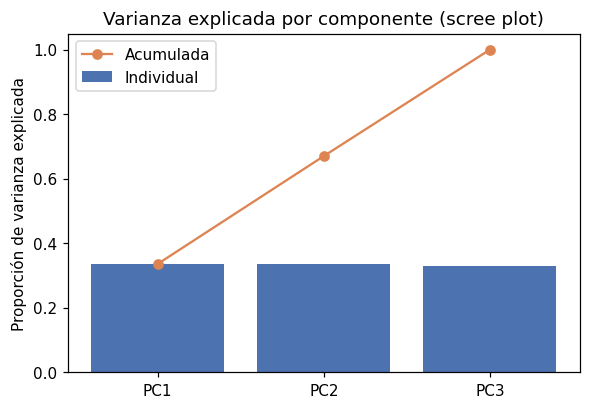

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([f"PC{i+1}" for i in range(len(varianza))], varianza, color="#4C72B0", label="Individual")
ax.plot([f"PC{i+1}" for i in range(len(varianza))], varianza_acum, color="#DD8452",
        marker="o", label="Acumulada")
ax.set_ylabel("Proporción de varianza explicada")
ax.set_title("Varianza explicada por componente (scree plot)")
ax.legend()
plt.show()


**Interpretación de la varianza explicada:** las tres componentes
explican una proporción **casi idéntica** de la varianza total (~33.6%, ~33.4% y ~33.0%
respectivamente). Esto **no es casual**: en el análisis exploratorio (notebook 03) ya se
había observado que `age`, `monthly_watch_time_mins` y `customer_support_tickets`
prácticamente no están correlacionadas entre sí (correlaciones cercanas a 0). Cuando las
variables originales son independientes entre sí, PCA no encuentra combinaciones lineales
que concentren la varianza en pocas componentes — cada componente termina explicando
aproximadamente la misma proporción, cercana a 1/n_variables (1/3 ≈ 33.3%). Es decir,
**PCA confirma cuantitativamente** lo que el EDA ya sugería cualitativamente: no hay
redundancia entre estas tres variables, por lo que **no es posible reducir la
dimensionalidad de forma eficiente** sin perder información relevante.

## 3. Interpretación de las componentes (cargas)

In [6]:
cargas = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(varianza))],
    index=num_cols
)
cargas.round(3)


**Interpretación de las cargas:** `PC1` combina principalmente `age`
(carga 0.75) y `customer_support_tickets` (carga 0.57), con un aporte menor de
`monthly_watch_time_mins`. `PC2` está dominada por `customer_support_tickets` (carga
0.80). `PC3` combina `age` y `monthly_watch_time_mins` en sentidos opuestos. Ninguna
componente está dominada exclusivamente por una sola variable original con las otras dos
en cero, lo cual es consistente con la ausencia de correlación entre las variables: cada
componente termina siendo una mezcla relativamente pareja de las tres.

## 4. Visualización en el plano de las dos primeras componentes

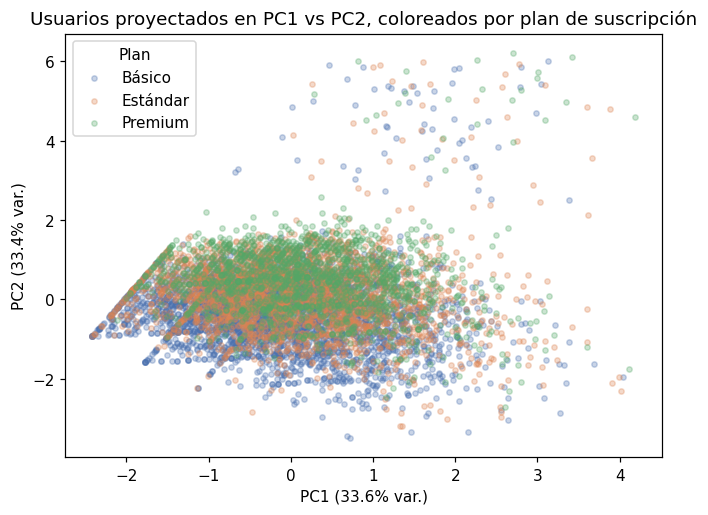

In [7]:
fig, ax = plt.subplots(figsize=(7, 5))
colores = {"Básico": "#4C72B0", "Estándar": "#DD8452", "Premium": "#55A868"}
for plan, color in colores.items():
    mask = df["subscription_plan"] == plan
    ax.scatter(componentes[mask.values, 0], componentes[mask.values, 1],
               alpha=0.3, s=12, label=plan, color=color)
ax.set_xlabel(f"PC1 ({varianza[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({varianza[1]*100:.1f}% var.)")
ax.set_title("Usuarios proyectados en PC1 vs PC2, coloreados por plan de suscripción")
ax.legend(title="Plan")
plt.show()


**Interpretación:** en el plano PC1–PC2 no se observan agrupamientos
(clusters) separados por plan de suscripción; los tres colores se superponen en toda la
nube de puntos. Esto confirma, ahora en el espacio reducido, lo que ya se había
observado en el EDA: **el plan de suscripción no se explica por una combinación lineal
de edad, consumo y tickets de soporte**. La reducción de dimensionalidad no revela
estructura oculta adicional en este dataset con las variables numéricas disponibles.


## 5. Síntesis de la etapa de PCA

- Variables utilizadas: `age`, `monthly_watch_time_mins`, `customer_support_tickets`.
- Escalamiento: `StandardScaler` (necesario por la diferencia de unidades/escalas).
- Varianza explicada: prácticamente uniforme entre las 3 componentes (~33% cada una),
  reflejo directo de la baja correlación entre las variables originales.
- Conclusión de la etapa: **no conviene reducir dimensionalidad** en este subconjunto de
  variables, ya que se perdería información sin ganar interpretabilidad; se necesitarían
  las 3 componentes para conservar el 100% de la varianza. Este resultado en sí mismo es
  un hallazgo válido del proyecto, no una limitación técnica del método.
